In [3]:
from tensorflow import keras # just to load the MNIST dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# importing from scikit-learn
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB, ComplementNB

# Data preparation 
- using tensorflow keras library to load the data
- simple normalization for each pixel to be in range [0,1]

In [4]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [5]:
x_train = x_train.reshape(-1, 784).astype("float32") / 255.0
x_test = x_test.reshape(-1, 784).astype("float32") / 255.0

In [8]:
print(x_train.shape, y_train.shape, x_test.shape, x_train.shape)

(60000, 784) (60000,) (10000, 784) (60000, 784)


# Classifying:

## Decision Tree Classifier - 88.3%

In [5]:
results = []
check_depths = 20
for depth in range(1,check_depths+1):
    model_tree = tree.DecisionTreeClassifier(max_depth = depth)
    model_tree.fit(x_train, y_train)
    y_hat = model_tree.predict(x_test)
    print(f'Accuracy of the model of max_depth = {depth} is {accuracy_score(y_test, y_hat)*100}%')
    results.append(accuracy_score(y_test, y_hat)*100)

Accuracy of the model of max_depth = 1 is 19.939999999999998%
Accuracy of the model of max_depth = 2 is 34.47%
Accuracy of the model of max_depth = 3 is 49.53%
Accuracy of the model of max_depth = 4 is 59.57%
Accuracy of the model of max_depth = 5 is 67.47%
Accuracy of the model of max_depth = 6 is 74.15%
Accuracy of the model of max_depth = 7 is 78.51%
Accuracy of the model of max_depth = 8 is 81.83%
Accuracy of the model of max_depth = 9 is 85.00999999999999%
Accuracy of the model of max_depth = 10 is 86.6%
Accuracy of the model of max_depth = 11 is 87.38%
Accuracy of the model of max_depth = 12 is 87.68%
Accuracy of the model of max_depth = 13 is 87.87%
Accuracy of the model of max_depth = 14 is 88.11%
Accuracy of the model of max_depth = 15 is 88.32%
Accuracy of the model of max_depth = 16 is 88.22%
Accuracy of the model of max_depth = 17 is 88.03999999999999%
Accuracy of the model of max_depth = 18 is 87.88%
Accuracy of the model of max_depth = 19 is 88.16000000000001%
Accuracy of

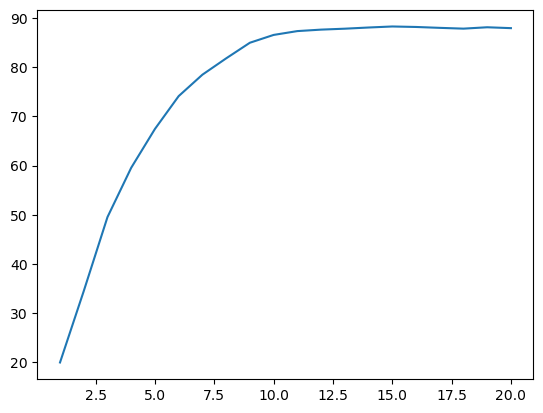

In [6]:
plt.plot(np.arange(1,check_depths+1, 1, dtype=np.int32), results)

In [15]:
model_tree = DecisionTreeClassifier(max_depth = 17)
model_tree.fit(x_train, y_train)
y_hat = model_tree.predict(x_test)

In [17]:
print("Confusion matrix:\n%s" % confusion_matrix(y_test, y_hat))

Confusion matrix:
[[ 917    0   10    3    6   14   10    3    9    8]
 [   0 1098   10    5    1    6    6    4    5    0]
 [   9   11  880   32   20    9   11   30   22    8]
 [   8    6   29  866   11   44    1   12   18   15]
 [   7    4    6    6  865    8   16    6   21   43]
 [  13   11    8   41   10  739   24    6   22   18]
 [  23    6    8    8   23   24  838    2   23    3]
 [   2   11   24   13    5    4    3  940    6   20]
 [  14    5   29   38   17   28   17    9  781   36]
 [  14    4    8   18   34    6    8   18   22  877]]


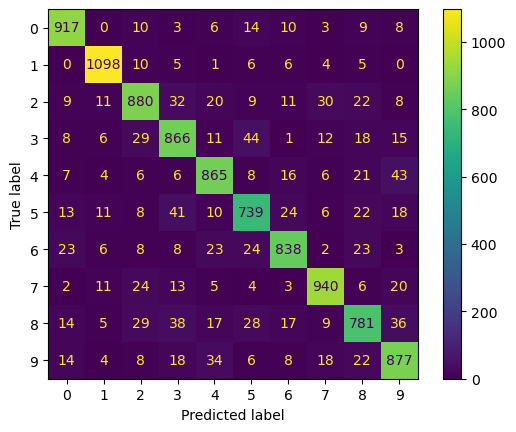

In [19]:
conf_matrix = confusion_matrix(y_test, y_hat, labels=model_tree.classes_)
res = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=model_tree.classes_)
res.plot()

## Random Forest Classifier - 96.5% 

In [12]:
model_forest = RandomForestClassifier(n_estimators=30)
model_forest.fit(x_train, y_train)
y_hat = model_forest.predict(x_test)
print(f'Accuracy of the model is {accuracy_score(y_test, y_hat)*100}%')

Accuracy of the model is 96.50999999999999%


## Logistic Regression - 92.6%

In [19]:
model_logistic = LogisticRegression(max_iter=1000)#
model_logistic.fit(x_train, y_train)
y_hat = model_logistic.predict(x_test)
print(f'Accuracy of the model is {accuracy_score(y_test, y_hat)*100}%')

Accuracy of the model is 92.64%


## K-nearest neighbors - 97%

In [25]:
model_knn = KNeighborsClassifier()
model_knn.fit(x_train, y_train)
y_hat  = model_knn.predict(x_test)
print(f'Accuracy of the model is {accuracy_score(y_test, y_hat)*100}%')

Accuracy of the model is 96.88%


In [26]:
neigh = np.arange(1,11,1)
for n in neigh:
    model_knn = KNeighborsClassifier(n_neighbors = n)
    model_knn.fit(x_train, y_train)
    y_hat  = model_knn.predict(x_test)
    print(f'Accuracy of the model is {accuracy_score(y_test, y_hat)*100}%')

Accuracy of the model is 96.91%
Accuracy of the model is 96.27%
Accuracy of the model is 97.05%
Accuracy of the model is 96.82%
Accuracy of the model is 96.88%
Accuracy of the model is 96.77%
Accuracy of the model is 96.94%
Accuracy of the model is 96.7%
Accuracy of the model is 96.59%
Accuracy of the model is 96.65%


## Support Vector Machine - 97.9%

In [28]:
model_svm = svm.SVC()
model_svm.fit(x_train, y_train)
y_hat  = model_svm.predict(x_test)
print(f'Accuracy of the model is {accuracy_score(y_test, y_hat)*100}%')

Accuracy of the model is 97.92%


## Naive Bayeses - best result 84.1%

In [39]:
model_bayes = BernoulliNB()
model_bayes.fit(x_train, y_train)
y_hat  = model_bayes.predict(x_test)
print(f'Accuracy of the model is {accuracy_score(y_test, y_hat)*100}%')
model_bayes = GaussianNB()
model_bayes.fit(x_train, y_train)
y_hat  = model_bayes.predict(x_test)
print(f'Accuracy of the model is {accuracy_score(y_test, y_hat)*100}%')
model_bayes = MultinomialNB()
model_bayes.fit(x_train, y_train)
y_hat  = model_bayes.predict(x_test)
print(f'Accuracy of the model is {accuracy_score(y_test, y_hat)*100}%')
model_bayes = ComplementNB()
model_bayes.fit(x_train, y_train)
y_hat  = model_bayes.predict(x_test)
print(f'Accuracy of the model is {accuracy_score(y_test, y_hat)*100}%')

Accuracy of the model is 84.13000000000001%
Accuracy of the model is 55.58%
Accuracy of the model is 83.57%
Accuracy of the model is 72.86%


### Out of Scikit-learn library Random Forest Classifier, K-nearest neighbors and Support Vector Machine achieved the best results classifying MNIST handwritten digits.